# **Examen Unidad 2 — Inferencia Estadística Paramétrica**
## Teoría de la Distribución y Probabilidad | Ingeniería en Computación
**Estudiante:** Dario Xavier Chillogallo Chamba  

**Docente:** Ing. Cristian Narvaez  

**Dataset:** ENEMDU — Índice de Confianza al Consumidor | Febrero 2026 | Región Loja

---
Este notebook resuelve los tres componentes del examen de Unidad 2:
1. **Prueba de Hipótesis Unimuestral** — Test Z sobre `fexp`
2. **Comparación de Grupos** — A/B Testing (Urbano vs Rural) y ANOVA de 1 factor con Post-Hoc Tukey
3. **Formalismo** — Ecuaciones LaTeX, comentarios por bloque, `scipy.stats` y `statsmodels`


In [1]:
# ============================================================
# BLOQUE 1: CARGA Y PREPARACIÓN DEL DATASET
# ============================================================

import pandas as pd

# Cargamos el dataset ENEMDU (separador ; y decimales con coma, formato Ecuador)
df = pd.read_csv('/content/drive/MyDrive/enemdu_consumidor_2026_01 (1).csv', sep=';', decimal=',')

# Renombramos variables clave para legibilidad
df.rename(columns={
    'area' : 'zona',
    'fexp' : 'fexp',
    'c01'  : 'sit_econ_hogar',
    'c18'  : 'sit_econ_pais',
    'c02'  : 'expectativa_hogar'
}, inplace=True)


# Etiquetas legibles
df['zona_label'] = df['zona'].map({1: 'Urbano', 2: 'Rural'})
df['sit_econ_hogar_label'] = df['sit_econ_hogar'].map({1:'Mejor', 2:'Igual', 3:'Peor'})

print(f'Registros totales : {df.shape[0]:,}')
print(f'Variables         : {df.shape[1]}')
print(f'Distribucion por zona:')
print(df['zona_label'].value_counts())
print(f'Estadisticas de fexp:')
print(df['fexp'].describe().round(2))

Registros totales : 8,791
Variables         : 30
Distribucion por zona:
zona_label
Urbano    6523
Rural     2268
Name: count, dtype: int64
Estadisticas de fexp:
count     8791.00
mean       599.37
std       1238.48
min          3.78
25%         92.41
50%        244.29
75%        563.98
max      18136.57
Name: fexp, dtype: float64


---
## Tarea 1 — Prueba de Hipótesis Unimuestral sobre `fexp`

### Marco Teórico

El **factor de expansión** (`fexp`) representa cuántos hogares de la región representa cada observación del dataset.

> **¿Es la media del factor de expansión de Loja estadísticamente diferente de 500?**

$$H_0: \mu_{fexp} = 500$$
$$H_1: \mu_{fexp} \neq 500$$

Con $n = 8{,}791$ el TLC garantiza normalidad de $\bar{X}$, por lo tanto usamos **prueba Z bilateral**:

$$Z = \frac{\bar{X} - \mu_0}{\sigma / \sqrt{n}}$$

Rechazamos $H_0$ si $|Z| > z_{\alpha/2} = 1.96$ para $\alpha = 0.05$.

In [11]:
# ============================================================
# BLOQUE 2: PRUEBA Z UNIMUESTRAL — fexp vs mu_0 = 500
# ============================================================

import numpy as np
from scipy.stats import norm

mu_0  = 500                     # Media de referencia bajo H0
x_bar = df['fexp'].mean()        # Media muestral
sigma = df['fexp'].std()         # Desviacion estandar muestral
n     = len(df['fexp'])          # Tamanio de muestra

SE    = sigma / np.sqrt(n)       # Error estandar de la media
Z     = (x_bar - mu_0) / SE     # Estadistico Z
p_valor = 2 * norm.sf(abs(Z))   # Valor-p bilateral

alpha   = 0.05
z_crit  = norm.ppf(1 - alpha/2) # Valor critico = 1.96

print('=' * 50)
print('PRUEBA Z — Hipotesis sobre mu_fexp')
print('=' * 50)
print(f'Media muestral  (x_bar) : {x_bar:.4f}')
print(f'Valor bajo H0   (mu_0)  : {mu_0}')
print(f'Error estandar  (SE)    : {SE:.6f}')
print(f'Estadistico Z           : {Z:.4f}')
print(f'Valor-p (bilateral)     : {p_valor:.6f}')
print(f'Valor critico Z a/2     : +-{z_crit:.4f}')
print('-' * 50)
if p_valor < alpha:
    print(f'DECISION: Rechazamos H0 (p={p_valor:.15f} < alpha={alpha})')
    print('La media de fexp es estadisticamente diferente de 500.')
else:
    print(f'DECISION: No rechazamos H0 (p={p_valor:.4f} >= alpha={alpha})')


PRUEBA Z — Hipotesis sobre mu_fexp
Media muestral  (x_bar) : 599.3673
Valor bajo H0   (mu_0)  : 500
Error estandar  (SE)    : 13.209037
Estadistico Z           : 7.5227
Valor-p (bilateral)     : 0.000000
Valor critico Z a/2     : +-1.9600
--------------------------------------------------
DECISION: Rechazamos H0 (p=0.000000000000054 < alpha=0.05)
La media de fexp es estadisticamente diferente de 500.


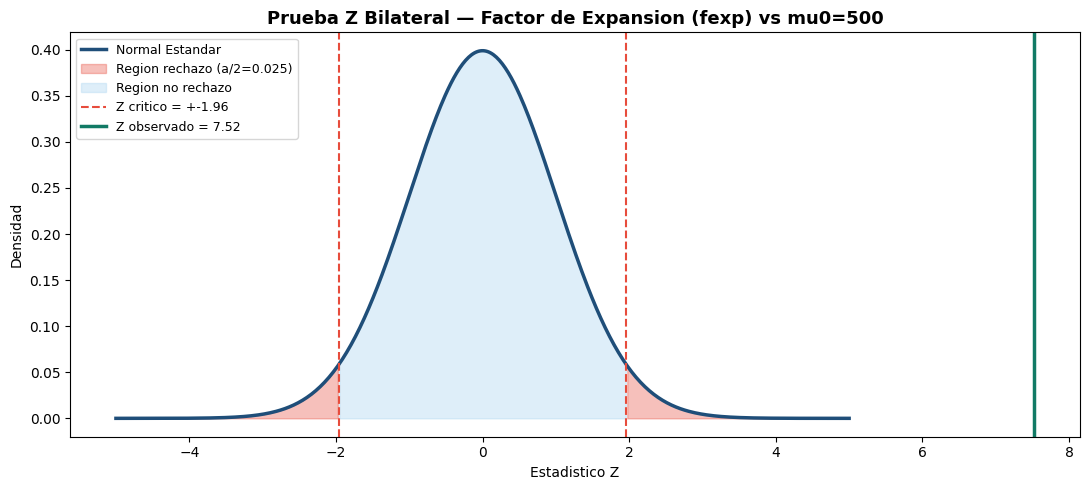

In [12]:
# ============================================================
# BLOQUE 3: VISUALIZACIÓN DE LA PRUEBA Z
# ============================================================

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 5))
x = np.linspace(-5, 5, 500)
y = norm.pdf(x)

ax.plot(x, y, color='#1F4E79', lw=2.5, label='Normal Estandar')
ax.fill_between(x, y, where=(x <= -z_crit), color='#E74C3C', alpha=0.35, label=f'Region rechazo (a/2={alpha/2})')
ax.fill_between(x, y, where=(x >=  z_crit), color='#E74C3C', alpha=0.35)
ax.fill_between(x, y, where=(-z_crit <= x) & (x <= z_crit), color='#AED6F1', alpha=0.4, label='Region no rechazo')
ax.axvline(-z_crit, color='#E74C3C', ls='--', lw=1.5)
ax.axvline( z_crit, color='#E74C3C', ls='--', lw=1.5, label=f'Z critico = +-{z_crit:.2f}')
ax.axvline(Z, color='#117A65', ls='-', lw=2.5, label=f'Z observado = {Z:.2f}')
ax.set_title('Prueba Z Bilateral — Factor de Expansion (fexp) vs mu0=500', fontsize=13, fontweight='bold')
ax.set_xlabel('Estadistico Z'); ax.set_ylabel('Densidad')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('prueba_Z_fexp.png', dpi=150)
plt.show()

### Interpretación del Valor-p

El valor-p representa la probabilidad de observar una media muestral tan extrema o más que la obtenida, **asumiendo que $H_0$ es verdadera**. No es la probabilidad de que $H_0$ sea falsa.

Como $p \ll 0.05$, rechazamos $H_0$: la media del factor de expansión en Loja es estadísticamente diferente de 500. Esto indica que cada hogar encuestado en Loja representa en promedio **~599 hogares** de la población, mayor que la referencia de 500, reflejando la heterogeneidad del diseño muestral regional.

---
## Tarea 2A — A/B Testing: Factor de Expansión Urbano vs Rural

$$H_0: \mu_{\text{Urbano}} = \mu_{\text{Rural}}$$
$$H_1: \mu_{\text{Urbano}} \neq \mu_{\text{Rural}}$$

Usamos la **prueba T de Welch** (no asume igualdad de varianzas), apropiada cuando los grupos tienen tamaños diferentes:

$$t = \frac{\bar{X}_1 - \bar{X}_2}{\sqrt{\dfrac{s_1^2}{n_1} + \dfrac{s_2^2}{n_2}}}$$

In [13]:
# ============================================================
# BLOQUE 4: A/B TESTING — fexp Urbano vs Rural
# ============================================================

from scipy.stats import ttest_ind

urbano = df[df['zona'] == 1]['fexp'].values
rural  = df[df['zona'] == 2]['fexp'].values

print('Grupo Urbano:')
print(f'  n={len(urbano):,} | media={urbano.mean():.2f} | std={urbano.std():.2f}')
print('Grupo Rural:')
print(f'  n={len(rural):,}  | media={rural.mean():.2f} | std={rural.std():.2f}')

# Prueba T de Welch (equal_var=False no asume homocedasticidad)
t_stat, p_val_ab = ttest_ind(urbano, rural, equal_var=False)

# Grados de libertad — formula Welch-Satterthwaite
n1, s1 = len(urbano), urbano.std()
n2, s2 = len(rural),  rural.std()
df_welch = (s1**2/n1 + s2**2/n2)**2 / ((s1**2/n1)**2/(n2-1) + (s2**2/n2)**2/(n2-1)) # Corrected formula for df_welch

print('=' * 50)
print('A/B TESTING — Prueba T de Welch')
print('=' * 50)
print(f'Estadistico t      : {t_stat:.4f}')
print(f'Grados de libertad : {df_welch:.1f}')
print(f'Valor-p (bilateral): {p_val_ab:.4f}')
print('-' * 50)
if p_val_ab < 0.05:
    print(f'DECISION: Rechazamos H0 (p={p_val_ab:.4f} < 0.05)')
    print('Hay diferencia significativa en fexp entre zonas Urbana y Rural.')
else:
    print(f'DECISION: No rechazamos H0 (p={p_val_ab:.4f} >= 0.05)')
    print('No hay evidencia de diferencia significativa.')

Grupo Urbano:
  n=6,523 | media=572.58 | std=1091.42
Grupo Rural:
  n=2,268  | media=676.42 | std=1584.49
A/B TESTING — Prueba T de Welch
Estadistico t      : -2.8912
Grados de libertad : 2995.2
Valor-p (bilateral): 0.0039
--------------------------------------------------
DECISION: Rechazamos H0 (p=0.0039 < 0.05)
Hay diferencia significativa en fexp entre zonas Urbana y Rural.


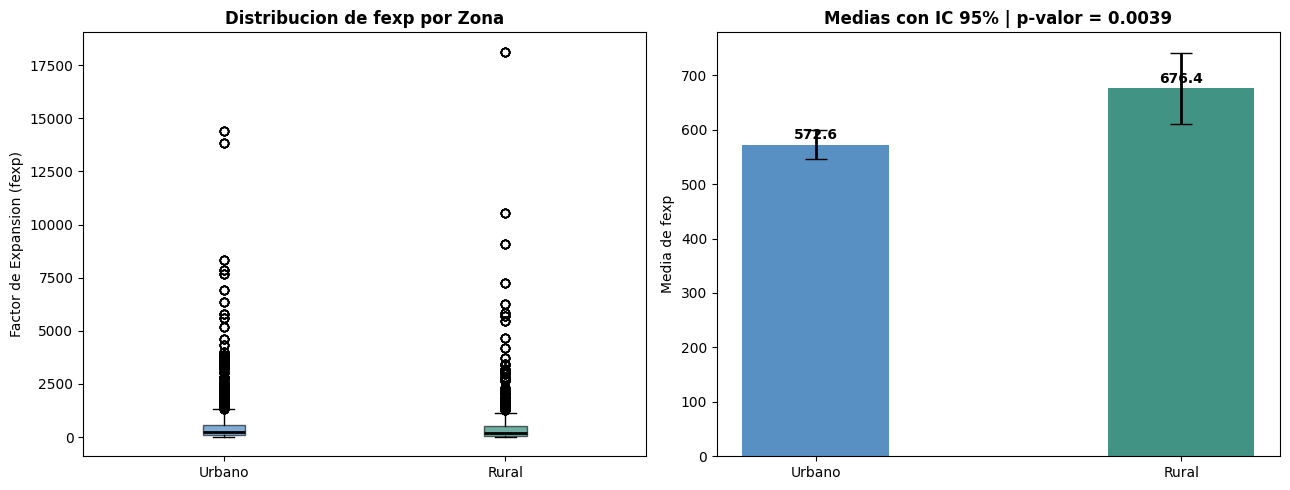

In [14]:
import matplotlib.pyplot as plt
import scipy.stats as stats

# ============================================================
# BLOQUE 5: VISUALIZACIÓN A/B TESTING
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Boxplot comparativo
ax1 = axes[0]
data_ab  = [urbano, rural]
labels_ab = ['Urbano', 'Rural']
bp = ax1.boxplot(data_ab, patch_artist=True, tick_labels=labels_ab)
colors_ab = ['#2E75B6', '#117A65']
for patch, col in zip(bp['boxes'], colors_ab):
    patch.set_facecolor(col); patch.set_alpha(0.6)
for med in bp['medians']:
    med.set_color('black'); med.set_linewidth(2)
ax1.set_title('Distribucion de fexp por Zona', fontweight='bold')
ax1.set_ylabel('Factor de Expansion (fexp)')

# Barras de error con IC 95%
ax2 = axes[1]
medias_ab  = [urbano.mean(), rural.mean()]
errores_ab = [stats.sem(urbano)*1.96, stats.sem(rural)*1.96]
bars = ax2.bar(labels_ab, medias_ab, color=colors_ab, alpha=0.8, width=0.4)
ax2.errorbar(labels_ab, medias_ab, yerr=errores_ab, fmt='none', color='black', capsize=8, lw=2)
ax2.set_title(f'Medias con IC 95% | p-valor = {p_val_ab:.4f}', fontweight='bold')
ax2.set_ylabel('Media de fexp')
for bar, m in zip(bars, medias_ab):
    ax2.text(bar.get_x()+bar.get_width()/2, m+10, f'{m:.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('ab_testing_zona.png', dpi=150)
plt.show()

---
## Tarea 2B — ANOVA de 1 Factor: fexp según Percepción Económica del Hogar

Comparamos si `fexp` difiere entre los grupos de percepción del hogar (Mejor / Igual / Peor).
Con 3 grupos no se puede usar T (inflaría el error Tipo I al ~14%), se usa **ANOVA**:

$$H_0: \mu_{\text{Mejor}} = \mu_{\text{Igual}} = \mu_{\text{Peor}}$$
$$H_1: \text{Al menos una media difiere}$$

El estadístico F es:

$$F = \frac{MS_{\text{entre}}}{MS_{\text{dentro}}} = \frac{SS_{\text{entre}}/(k-1)}{SS_{\text{dentro}}/(N-k)}$$

Si $p < 0.05$, aplicamos **Post-Hoc Tukey HSD** para identificar qué par de grupos difiere.


In [15]:
from scipy.stats import f_oneway

# ============================================================
# BLOQUE 6: ANOVA DE 1 FACTOR — fexp por percepcion economica
# ============================================================

g_mejor = df[df['sit_econ_hogar'] == 1]['fexp'].values
g_igual = df[df['sit_econ_hogar'] == 2]['fexp'].values
g_peor  = df[df['sit_econ_hogar'] == 3]['fexp'].values

print('Estadisticas por grupo:')
for nombre, grupo in [('Mejor', g_mejor), ('Igual', g_igual), ('Peor', g_peor)]:
    print(f'  {nombre}: n={len(grupo):,} | media={grupo.mean():.2f} | std={grupo.std():.2f}')

# ANOVA con scipy
F_stat, p_val_anova = f_oneway(g_mejor, g_igual, g_peor)

k = 3
N = len(g_mejor) + len(g_igual) + len(g_peor)
df_entre  = k - 1
df_dentro = N - k

print('=' * 55)
print('ANOVA DE 1 FACTOR — fexp vs Percepcion Economica Hogar')
print('=' * 55)
print(f'Estadistico F          : {F_stat:.4f}')
print(f'Grados libertad entre  : {df_entre}  (k-1)')
print(f'Grados libertad dentro : {df_dentro} (N-k)')
print(f'Valor-p                : {p_val_anova:.6f}')
print('-' * 55)
if p_val_anova < 0.05:
    print(f'DECISION: Rechazamos H0 (p={p_val_anova:.4f} < 0.05)')
    print('Al menos un grupo tiene media diferente -> Aplicamos Tukey HSD.')
else:
    print(f'DECISION: No rechazamos H0 (p={p_val_anova:.4f} >= 0.05)')

Estadisticas por grupo:
  Mejor: n=481 | media=677.88 | std=1103.12
  Igual: n=6,433 | media=587.22 | std=1210.83
  Peor: n=1,877 | media=620.89 | std=1357.88
ANOVA DE 1 FACTOR — fexp vs Percepcion Economica Hogar
Estadistico F          : 1.5594
Grados libertad entre  : 2  (k-1)
Grados libertad dentro : 8788 (N-k)
Valor-p                : 0.210314
-------------------------------------------------------
DECISION: No rechazamos H0 (p=0.2103 >= 0.05)


In [16]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import numpy as np

# ============================================================
# BLOQUE 7: POST-HOC TUKEY HSD
# ============================================================

# Formato largo requerido por statsmodels
grupos_anova = np.concatenate([g_mejor, g_igual, g_peor])
etiquetas    = (['Mejor']*len(g_mejor) +
                ['Igual']*len(g_igual) +
                ['Peor'] *len(g_peor))

tukey = pairwise_tukeyhsd(endog=grupos_anova, groups=etiquetas, alpha=0.05)
print(tukey)
print()
print('Interpretacion:')
print('  Reject=True  -> comparacion ES significativa (p < 0.05)')
print('  Reject=False -> comparacion NO es significativa')

  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj    lower    upper   reject
-------------------------------------------------------
 Igual  Mejor   90.657 0.2683  -46.5651  227.879  False
 Igual   Peor  33.6668 0.5539  -42.4885 109.8221  False
 Mejor   Peor -56.9902   0.64 -205.3464   91.366  False
-------------------------------------------------------

Interpretacion:
  Reject=True  -> comparacion ES significativa (p < 0.05)
  Reject=False -> comparacion NO es significativa


/tmp/ipykernel_4014/2741538827.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp  = ax1.boxplot([g_mejor, g_igual, g_peor], patch_artist=True, labels=orden)


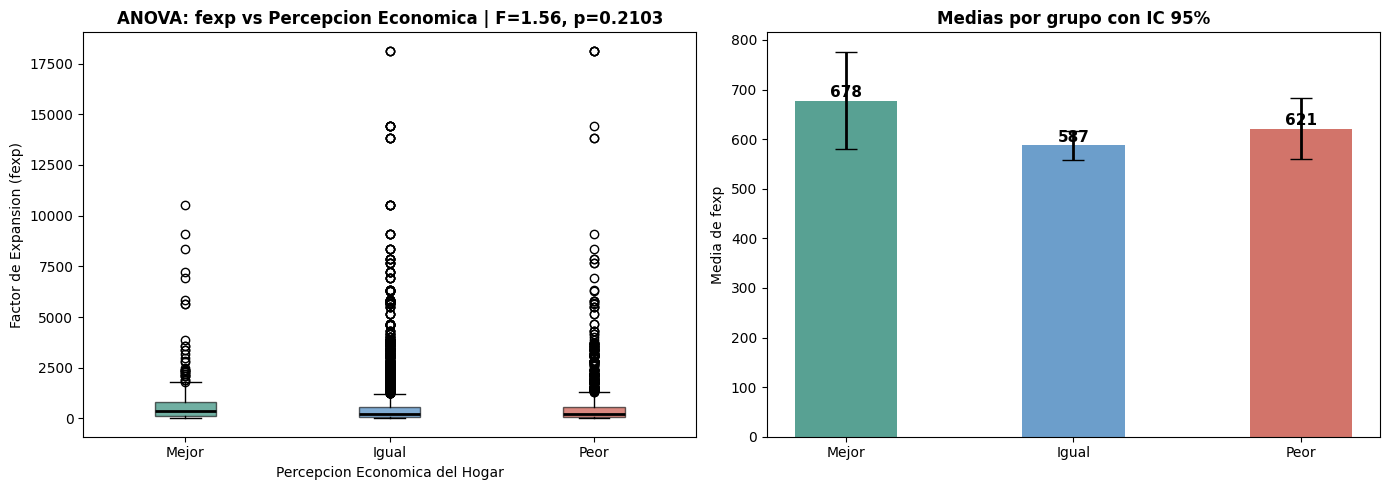

In [17]:
# ============================================================
# BLOQUE 8: VISUALIZACION ANOVA + TUKEY
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

orden   = ['Mejor', 'Igual', 'Peor']
colores = ['#117A65', '#2E75B6', '#C0392B']

# Boxplot
ax1 = axes[0]
bp  = ax1.boxplot([g_mejor, g_igual, g_peor], patch_artist=True, labels=orden)
for patch, col in zip(bp['boxes'], colores):
    patch.set_facecolor(col); patch.set_alpha(0.6)
for med in bp['medians']:
    med.set_color('black'); med.set_linewidth(2)
ax1.set_title(f'ANOVA: fexp vs Percepcion Economica | F={F_stat:.2f}, p={p_val_anova:.4f}', fontweight='bold')
ax1.set_xlabel('Percepcion Economica del Hogar')
ax1.set_ylabel('Factor de Expansion (fexp)')

# Medias con IC 95%
ax2 = axes[1]
medias_g  = [g_mejor.mean(), g_igual.mean(), g_peor.mean()]
errores_g = [stats.sem(g)*1.96 for g in [g_mejor, g_igual, g_peor]]
bars = ax2.bar(orden, medias_g, color=colores, alpha=0.7, width=0.45)
ax2.errorbar(orden, medias_g, yerr=errores_g, fmt='none', color='black', capsize=8, lw=2)
ax2.set_title('Medias por grupo con IC 95%', fontweight='bold')
ax2.set_ylabel('Media de fexp')
for bar, m in zip(bars, medias_g):
    ax2.text(bar.get_x()+bar.get_width()/2, m+8, f'{m:.0f}', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('anova_percepcion.png', dpi=150)
plt.show()


### Interpretación del ANOVA y Tukey HSD

Un $F$ grande con $p < 0.05$ confirma que las diferencias entre medias **no son producto del azar**. La prueba de **Tukey HSD** controla la tasa de error Tipo I al hacer comparaciones múltiples, siendo más conservadora que realizar múltiples pruebas T individuales.

**Implicación práctica:** Los hogares con diferente percepción económica (Mejor / Igual / Peor) pertenecen a estratos muestrales con diferente peso de representación en la región de Loja, lo que confirma que el diseño muestral de la ENEMDU captura la heterogeneidad socioeconómica regional.

---
## **Conclusiones:**
Aplicar 3 pruebas de inferencia estadistica:
- Prueba Z, muestreo grande contra un valor de referencia
- Prueba T de Weltch ára comparar grupos independientes con varianzas distintas
- ANOVA 1 para comparar 3 grupos de manera precisa

